phi range: 0.55 0.64
p0: [0.3539245308730463, 1.0, 0.27495, 0.7200500000000001]
lb: [0.0, 0.0, 0.0, 0.6401]
ub: [1000000.0, 10.0, 0.5499, 0.8]
Fitted parameters: sigma_a = 0.0245, kappa = 0.8925, phi_alp = 0.0000, phi_mu = 0.6734
Parameter uncertainties: sigma_a_err = 0.4551, kappa_err = 1.2664, phi_alp_err = 8.9293, phi_mu_err = 0.0435
phi range: 0.49 0.57
p0: [1.2341321612312628, 1.0, 0.24495, 0.6850499999999999]
lb: [0.0, 0.0, 0.0, 0.5700999999999999]
ub: [1000000.0, 10.0, 0.4899, 0.8]
Fitted parameters: sigma_a = 0.0881, kappa = 1.2180, phi_alp = 0.0000, phi_mu = 0.5749
Parameter uncertainties: sigma_a_err = 1.0048, kappa_err = 0.5842, phi_alp_err = 7.0310, phi_mu_err = 0.0032
phi range: 0.38 0.44
p0: [1.02980692591263, 1.0, 0.18995, 0.62005]
lb: [0.0, 0.0, 0.0, 0.4401]
ub: [1000000.0, 10.0, 0.3799, 0.8]
Fitted parameters: sigma_a = 0.0525, kappa = 0.8311, phi_alp = 0.0000, phi_mu = 0.4513
Parameter uncertainties: sigma_a_err = 0.7070, kappa_err = 0.5062, phi_alp_err = 4.2670, phi_

C:\Users\myles\AppData\Local\Temp\ipykernel_75216\2704356506.py:141: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(df_10["phi"], df_10["sigma_y"], 's-', marker='o', linestyle='')
C:\Users\myles\AppData\Local\Temp\ipykernel_75216\2704356506.py:141: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "s-" (-> marker='s'). The keyword argument will take precedence.
  plt.plot(df_10["phi"], df_10["sigma_y"], 's-', marker='o', linestyle='')


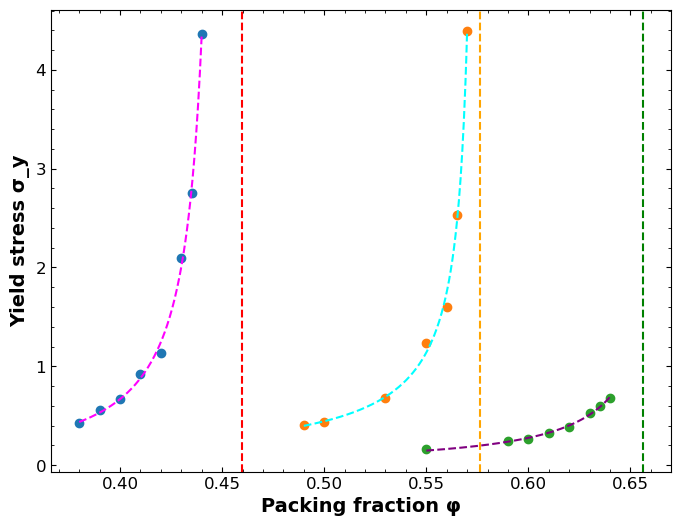

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

df_11 = pd.read_csv(r"C:\Users\myles\.vscode\DAQ\SenHon\1_1_extended_flowcurve.csv")
df_10 = pd.read_csv(r"C:\Users\myles\.vscode\DAQ\SenHon\1_0_flowcurve.csv")
df_00 = pd.read_csv(r"C:\Users\myles\.vscode\DAQ\SenHon\0_0_flowcurve.csv")

def model(phi, phi_J, beta):
    return 0.001*(1-phi/phi_J)**(-beta)

def yield_stress_model(phi, sigma_a, kappa, phi_alp, phi_mu):
    """
    Yield stress as a function of volume fraction in adhesive jamming model.
    
    Parameters:
    -----------
    phi : array-like
        Volume fraction(s)
    sigma_a : float
        Stress scale for peeling apart adhesive bonds (Pa)
    kappa : float
        Sensitivity parameter for jamming transition
    phi_alp : float
        Lower critical jamming concentration (particles stuck)
    phi_mu : float
        Upper critical jamming concentration (particles can roll)
    
    Returns:
    --------
    sigma_y : array-like
        Yield stress (Pa)
    
    Reference equation:
    σ_y = σ_a * ln[(φ_μ - φ_alp)/(φ - φ_alp)]^(-1/κ)
    """
    return sigma_a * np.log((phi_mu - phi_alp) / (phi - phi_alp)) ** (-1 / kappa)


# ============================================================================
# OPTIMIZATION FUNCTION
# ============================================================================

import numpy as np
from scipy.optimize import curve_fit

def fit_yield_stress(phi_data, sigma_y_data, sigma_err=None):
    phi = np.asarray(phi_data, float)
    y   = np.asarray(sigma_y_data, float)

    mask = np.isfinite(phi) & np.isfinite(y)
    phi, y = phi[mask], y[mask]

    eps = 1e-6
    phi_min, phi_max = float(phi.min()), float(phi.max())

    # bounds in SAME order as parameters: (sigma_a, kappa, phi_alp, phi_mu)
    lb = [0.0,  0.0,  0.0,          phi_max + 1e-4] 
    ub = [1e6, 10.0,  phi_min - 1e-4, 0.80]

    if not (lb[2] < ub[2]):
        raise ValueError(f"Invalid phi_alp bounds: lb={lb[2]} ub={ub[2]} (phi_min={phi_min})")
    if not (lb[3] < ub[3]):
        raise ValueError(f"Invalid phi_mu bounds: lb={lb[3]} ub={ub[3]} (phi_max={phi_max})")

    bounds = (lb, ub)

    # p0 strictly inside bounds
    p0 = [
        float(np.median(y)),
        1.0,
        (lb[2] + ub[2]) / 2.0,
        (lb[3] + ub[3]) / 2.0
    ]

    # optional weighting
    sigma = None
    abs_sigma = False
    if sigma_err is not None:
        sigma = np.asarray(sigma_err, float)[mask]
        if np.any(~np.isfinite(sigma)) or np.any(sigma <= 0):
            raise ValueError("sigma_err must be finite and > 0 everywhere.")
        abs_sigma = True

    # debug prints that immediately reveal the issue if it happens again
    print("phi range:", phi_min, phi_max)
    print("p0:", p0)
    print("lb:", lb)
    print("ub:", ub)

    popt, pcov = curve_fit(
        yield_stress_model,
        phi, y,
        p0=p0,
        bounds=bounds,
        sigma=sigma,
        absolute_sigma=abs_sigma,
        maxfev=20000
    )

    perr = np.sqrt(np.diag(pcov))
    return popt, pcov, perr


popt, pcov, perr = fit_yield_stress(df_00["phi"], df_00["sigma_y"])
print(f"Fitted parameters: sigma_a = {popt[0]:.4f}, kappa = {popt[1]:.4f}, phi_alp = {popt[2]:.4f}, phi_mu = {popt[3]:.4f}")
print(f"Parameter uncertainties: sigma_a_err = {perr[0]:.4f}, kappa_err = {perr[1]:.4f}, phi_alp_err = {perr[2]:.4f}, phi_mu_err = {perr[3]:.4f}")

popt2, pcov2, perr2 = fit_yield_stress(df_10["phi"], df_10["sigma_y"])
print(f"Fitted parameters: sigma_a = {popt2[0]:.4f}, kappa = {popt2[1]:.4f}, phi_alp = {popt2[2]:.4f}, phi_mu = {popt2[3]:.4f}")
print(f"Parameter uncertainties: sigma_a_err = {perr2[0]:.4f}, kappa_err = {perr2[1]:.4f}, phi_alp_err = {perr2[2]:.4f}, phi_mu_err = {perr2[3]:.4f}")

popt3, pcov3, perr3 = fit_yield_stress(df_11["phi"], df_11["sigma_y"])
print(f"Fitted parameters: sigma_a = {popt3[0]:.4f}, kappa = {popt3[1]:.4f}, phi_alp = {popt3[2]:.4f}, phi_mu = {popt3[3]:.4f}")
print(f"Parameter uncertainties: sigma_a_err = {perr3[0]:.4f}, kappa_err = {perr3[1]:.4f}, phi_alp_err = {perr3[2]:.4f}, phi_mu_err = {perr3[3]:.4f}")



"""# bounds: lower < upper for each parameter (phi_J, beta)
bounds_0_0 = ([0.650, 0.0], [0.660, 2])

params_0_0, _ = curve_fit(model, df_00["phi"], df_00["sigma_y"], p0=[0.656, 1.0], bounds=bounds_0_0, maxfev=100000)
x_fit_0_0 = np.linspace(df_00["phi"].min(), df_00["phi"].max(), 200)
y_fit_0_0 = model(x_fit_0_0, *params_0_0)
print(f"Fitted parameters for 0.0: phi_J = {params_0_0[0]:.4f}, beta = {params_0_0[1]:.4f}")"""

x_fit_0_0 = np.linspace(df_00["phi"].min(), df_00["phi"].max(), 200)
y_2_fit_0_0 = yield_stress_model(x_fit_0_0, *popt)

x_fit_1_0 = np.linspace(df_10["phi"].min(), df_10["phi"].max(), 200)
y_2_fit_1_0 = yield_stress_model(x_fit_1_0, *popt2)

x_fit_1_1 = np.linspace(df_11["phi"].min(), df_11["phi"].max(), 200)
y_2_fit_1_1 = yield_stress_model(x_fit_1_1, *popt3)


plt.figure(figsize=(8,6))

plt.plot(df_11["phi"], df_11["sigma_y"], marker = 'o', linestyle='')
plt.plot(df_10["phi"], df_10["sigma_y"], 's-', marker='o', linestyle='')
plt.plot(df_00["phi"], df_00["sigma_y"], marker='o', linestyle='')
#plt.plot(x_fit_0_0, y_fit_0_0, label='Fit for 0.0', color='blue')
plt.plot(x_fit_0_0, y_2_fit_0_0, label='Adhesive Jamming Fit', color='purple', linestyle='--')
plt.plot(x_fit_1_0, y_2_fit_1_0, label='Adhesive Jamming Fit', color='cyan', linestyle='--')
plt.plot(x_fit_1_1, y_2_fit_1_1, label='Adhesive Jamming Fit', color='magenta', linestyle='--')

plt.axvline(x=0.45955965, color='red', linestyle='--', label='φ_J = 0.4596')
plt.axvline(x=0.57638227, color='orange', linestyle='--', label='φ_J = 0.5764')
plt.axvline(x=0.65608237, color='green', linestyle='--', label='φ_J = 0.6561')



"""plt.yscale("log")
plt.ylim(6e-1, 3e1)"""

plt.minorticks_on()
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)

plt.xlabel("Packing fraction φ", fontsize=14, fontweight='bold')
plt.ylabel("Yield stress σ_y", fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

<>:224: SyntaxWarning: invalid escape sequence '\p'
<>:225: SyntaxWarning: invalid escape sequence '\h'
<>:224: SyntaxWarning: invalid escape sequence '\p'
<>:225: SyntaxWarning: invalid escape sequence '\h'
C:\Users\myles\AppData\Local\Temp\ipykernel_68956\818319817.py:224: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("Packing fraction $\phi$", fontsize=14, fontweight='bold')
C:\Users\myles\AppData\Local\Temp\ipykernel_68956\818319817.py:225: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel("Yield stress $\hat{\sigma_y}$", fontsize=14, fontweight='bold')


0_0 popt: [8.84651359e-02 1.13122247e+00 4.62336227e-17 6.46689067e-01] perr: [5.83824727e-01 2.80545942e-01 4.28115461e+00 2.07202378e-03]
1_0 popt: [8.80761403e-02 1.21799751e+00 2.05384537e-07 5.74888628e-01] perr: [1.00479501e+00 5.84225273e-01 7.03101167e+00 3.15682801e-03]
1_1 popt: [5.24544170e-02 8.31087928e-01 2.13067057e-08 4.51316667e-01] perr: [0.70699361 0.50618105 4.26703808 0.00695568]
Power law beta (0_0): 2.3492033679319717 +/- 0.021710675599485706
Power law beta (1_1): 3.024288591384525 +/- 0.018789820139004362


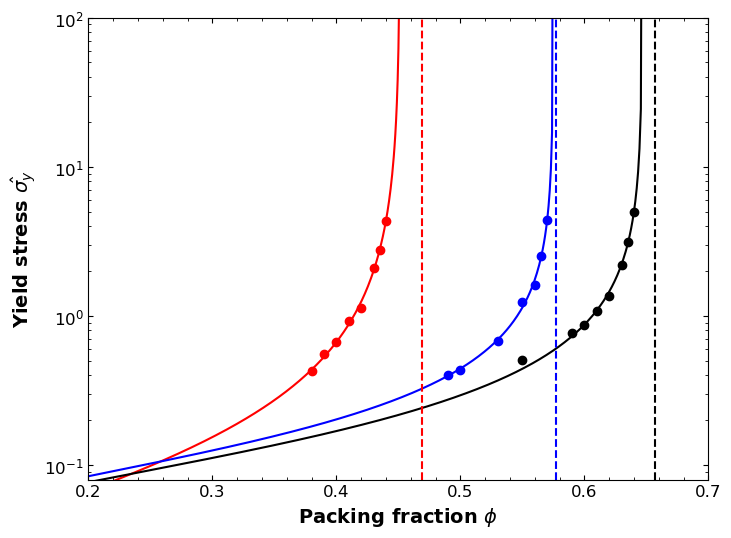

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

df_11 = pd.read_csv(r"C:\Users\myles\.vscode\DAQ\SenHon\1_1_extended_flowcurve.csv")
df_10 = pd.read_csv(r"C:\Users\myles\.vscode\DAQ\SenHon\1_0_flowcurve.csv")
df_00 = pd.read_csv(r"C:\Users\myles\.vscode\DAQ\SenHon\0_0_flowcurve.csv")

def model(phi, phi_J, beta):
    return 0.001*(1-phi/phi_J)**(-beta)

def yield_stress_model(phi, sigma_a, kappa, phi_alp, phi_mu):
    return sigma_a * np.log((phi_mu - phi_alp) / (phi - phi_alp)) ** (-1 / kappa)

# ============================================================================
# POWER LAW FIT (for 0_0 and 1_1)
# ============================================================================

def powerlaw_model(phi, beta, phi_J):
    return 0.001 * (1 - phi/phi_J)**(-beta)


def fit_powerlaw(phi_data, sigma_data, phi_J):
    
    phi = np.asarray(phi_data, float)
    y   = np.asarray(sigma_data, float)

    mask = np.isfinite(phi) & np.isfinite(y)
    phi, y = phi[mask], y[mask]

    # remove points too close to divergence
    valid = phi < (phi_J - 1e-4)
    phi = phi[valid]
    y   = y[valid]

    # fit only beta
    def model_beta(phi, beta):
        return powerlaw_model(phi, beta, phi_J)

    popt, pcov = curve_fit(
        model_beta,
        phi,
        y,
        p0=[2.0],
        bounds=([0],[10])
    )

    beta = popt[0]
    beta_err = np.sqrt(np.diag(pcov))[0]

    return beta, beta_err

# ============================================================================
# FIT
# ============================================================================

def fit_yield_stress(phi_data, sigma_y_data, sigma_err=None):
    phi = np.asarray(phi_data, float)
    y   = np.asarray(sigma_y_data, float)

    mask = np.isfinite(phi) & np.isfinite(y)
    phi, y = phi[mask], y[mask]

    phi_min, phi_max = float(phi.min()), float(phi.max())

    lb = [0.0,  0.0,  0.0,           phi_max + 1e-4]
    ub = [1e6, 10.0,  phi_min - 1e-4, 0.80]

    if not (lb[2] < ub[2]):
        raise ValueError(f"Invalid phi_alp bounds: lb={lb[2]} ub={ub[2]} (phi_min={phi_min})")
    if not (lb[3] < ub[3]):
        raise ValueError(f"Invalid phi_mu bounds: lb={lb[3]} ub={ub[3]} (phi_max={phi_max})")

    bounds = (lb, ub)

    p0 = [
        float(np.median(y)),
        1.0,
        (lb[2] + ub[2]) / 2.0,
        (lb[3] + ub[3]) / 2.0
    ]

    sigma = None
    abs_sigma = False
    if sigma_err is not None:
        sigma = np.asarray(sigma_err, float)[mask]
        if np.any(~np.isfinite(sigma)) or np.any(sigma <= 0):
            raise ValueError("sigma_err must be finite and > 0 everywhere.")
        abs_sigma = True

    popt, pcov = curve_fit(
        yield_stress_model,
        phi, y,
        p0=p0,
        bounds=bounds,
        sigma=sigma,
        absolute_sigma=abs_sigma,
        maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))
    return popt, pcov, perr

# fit each regime
popt00, pcov00, perr00 = fit_yield_stress(df_00["phi"], df_00["sigma_y"])
popt10, pcov10, perr10 = fit_yield_stress(df_10["phi"], df_10["sigma_y"])
popt11, pcov11, perr11 = fit_yield_stress(df_11["phi"], df_11["sigma_y"])

print("0_0 popt:", popt00, "perr:", perr00)
print("1_0 popt:", popt10, "perr:", perr10)
print("1_1 popt:", popt11, "perr:", perr11)

# ============================================================================
# POWER LAW FITS
# ============================================================================
# your “respective jamming fractions” (right endpoints for the plotted curves)
phiJ_11 = 0.469
phiJ_10 = 0.577
phiJ_00 = 0.657

beta00, beta00_err = fit_powerlaw(df_00["phi"], df_00["sigma_y"], phiJ_00)
beta11, beta11_err = fit_powerlaw(df_11["phi"], df_11["sigma_y"], phiJ_11)

print("Power law beta (0_0):", beta00, "+/-", beta00_err)
print("Power law beta (1_1):", beta11, "+/-", beta11_err)

# ============================================================================
# EXTRAPOLATION CONTROL
# ============================================================================

# left endpoint you want
PHI_LEFT = 0.20



def safe_curve(phi_grid, popt):
    """
    Evaluate yield_stress_model only where it's defined:
      phi > phi_alp and phi < phi_mu
    Else return NaN (so matplotlib will break the line).
    """
    sigma_a, kappa, phi_alp, phi_mu = popt
    phi_grid = np.asarray(phi_grid, float)
    y = np.full_like(phi_grid, np.nan, dtype=float)
    ok = (phi_grid > phi_alp) & (phi_grid < phi_mu)
    if np.any(ok):
        y[ok] = yield_stress_model(phi_grid[ok], *popt)
    return y

def make_phi_grid(popt, phiJ_right, n=400):
    """
    Build a grid from PHI_LEFT to the jamming fraction, but
    also respect the model’s domain using a tiny buffer.
    """
    _, _, phi_alp, phi_mu = popt

    # start: cannot go <= phi_alp
    start = max(PHI_LEFT, phi_alp + 1e-6)

    # end: cannot go >= phi_mu
    end = min(phiJ_right, phi_mu - 1e-6)

    if end <= start:
        # nothing to plot (model domain doesn't overlap desired range)
        return np.array([np.nan, np.nan])

    return np.linspace(start, end, n)

# grids that *try* to go to phi=0.36 and to each phiJ, but remain valid
x_fit_00 = make_phi_grid(popt00, phiJ_00)
y_fit_00 = safe_curve(x_fit_00, popt00)

x_fit_10 = make_phi_grid(popt10, phiJ_10)
y_fit_10 = safe_curve(x_fit_10, popt10)

x_fit_11 = make_phi_grid(popt11, phiJ_11)
y_fit_11 = safe_curve(x_fit_11, popt11)

# power law grids
phi_pow_00 = np.linspace(PHI_LEFT, phiJ_00-1e-4, 400)
phi_pow_11 = np.linspace(PHI_LEFT, phiJ_11-1e-4, 400)

sigma_pow_00 = powerlaw_model(phi_pow_00, beta00, phiJ_00)
sigma_pow_11 = powerlaw_model(phi_pow_11, beta11, phiJ_11)

# ============================================================================
# PLOT
# ============================================================================

plt.figure(figsize=(8,6))

# raw data
plt.plot(df_11["phi"], df_11["sigma_y"], marker='o', color='red', linestyle='', label='data 1_1')
plt.plot(df_10["phi"], df_10["sigma_y"], marker='o', color='blue', linestyle='', label='data 1_0')
plt.plot(df_00["phi"], df_00["sigma_y"], marker='o', color='black', linestyle='', label='data 0_0')

# extrapolated fits (now extended)
plt.plot(x_fit_11, y_fit_11, linestyle='-', color='red', label='fit 1_1')
plt.plot(x_fit_10, y_fit_10, linestyle='-', color='blue', label='fit 1_0')
plt.plot(x_fit_00, y_fit_00, linestyle='-', color='black', label='fit 0_0')

"""# power-law overlays
plt.plot(phi_pow_00, sigma_pow_00, linestyle='--', color='black',
         label=f'power law 0_0 (β={beta00:.2f})')

plt.plot(phi_pow_11, sigma_pow_11, linestyle='--', color='red',
         label=f'power law 1_1 (β={beta11:.2f})')
"""

# jamming fractions
plt.axvline(x=phiJ_11, linestyle='--', color='red', label=f'φ_J(1_1) = {phiJ_11:.4f}')
plt.axvline(x=phiJ_10, linestyle='--', color='blue', label=f'φ_J(1_0) = {phiJ_10:.4f}')
plt.axvline(x=phiJ_00, linestyle='--', color='black', label=f'φ_J(0_0) = {phiJ_00:.4f}')


plt.minorticks_on()
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)
plt.xlim(0.20, 0.70)
plt.yscale("log")
plt.ylim(8e-2, 1e2)



plt.xlabel("Packing fraction $\phi$", fontsize=14, fontweight='bold')
plt.ylabel("Yield stress $\hat{\sigma_y}$", fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()